# Group Work 13: Variational Autoencoders and Diffusion Models

In this lab you will:
- Build and train a **Convolutional Variational Autoencoder (CNN-VAE)** on MNIST digits
- Explore the latent space through interpolation and generate new digits
- Understand the mathematics behind **Denoising Diffusion Probabilistic Models (DDPMs)**
- Implement the forward diffusion process and sample from a trained DDPM

**All random states must be set to 503.**

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(503)
np.random.seed(503)

In [2]:
data_path = 'data/'

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Section 1: Convolutional Variational Autoencoder

### Background

A **Variational Autoencoder (VAE)** learns a structured latent space.
The encoder maps each image to a *distribution* — mean $\mu$ and log-variance
$\log\sigma^2$ — from which a sample $z$ is drawn via the **reparameterization trick**:

$$z = \mu + \sigma \cdot \varepsilon, \qquad \varepsilon \sim N(0, I)$$

This makes sampling differentiable and allows end-to-end training.

### MNIST Dataset

MNIST contains 70 000 grayscale 28×28 images of handwritten digits (classes 0–9).

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


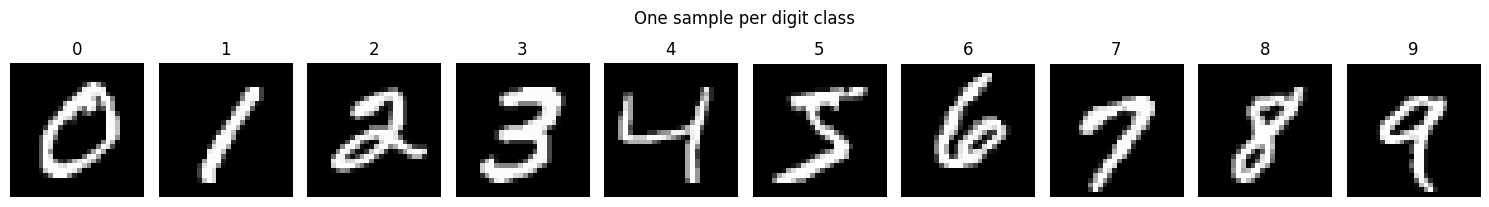

In [4]:
# Tutorial — one sample per digit class
_tf = transforms.ToTensor()
_ds = datasets.MNIST(root=data_path, train=True, download=True, transform=_tf)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for cls in range(10):
    idx = next(i for i, (_, y) in enumerate(_ds) if y == cls)
    axes[cls].imshow(_ds[idx][0].squeeze(), cmap='gray')
    axes[cls].set_title(str(cls))
    axes[cls].axis('off')
plt.suptitle("One sample per digit class", y=1.02)
plt.tight_layout()
plt.show()

### Exercise 1: Data Setup and Device Verification

**Tasks:**
1. Create `torchvision.datasets.MNIST` training and test datasets using `transforms.ToTensor()` and `data_path` as root.
2. Wrap both in `DataLoader` objects with `batch_size=128`. Use `shuffle=True` for training and `shuffle=False` for test.

**Variables to define:** `train_dataset`, `test_dataset`, `train_loader`, `test_loader`

**Use `torch.manual_seed(503)` and `np.random.seed(503)` at the top of your solution.**

In [5]:
torch.manual_seed(503)
np.random.seed(503)

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root=data_path, train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root=data_path, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Visible tests
assert len(train_dataset) == 60000, "Training set should have 60 000 samples"
assert len(test_dataset)  == 10000, "Test set should have 10 000 samples"
_xb, _yb = next(iter(train_loader))
assert _xb.shape == (128, 1, 28, 28), f"Unexpected batch shape: {_xb.shape}"
print(f"Device        : {device}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")
print("Exercise 1 tests passed.")
# Visible tests
assert len(train_dataset) == 60000, "Training set should have 60 000 samples"
assert len(test_dataset)  == 10000, "Test set should have 10 000 samples"
_xb, _yb = next(iter(train_loader))
assert _xb.shape == (128, 1, 28, 28), f"Unexpected batch shape: {_xb.shape}"
print(f"Device        : {device}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")
print("Exercise 1 tests passed.")

Device        : cuda
Train batches : 469
Test  batches : 79
Exercise 1 tests passed.
Device        : cuda
Train batches : 469
Test  batches : 79
Exercise 1 tests passed.


### CNN-VAE Architecture

#### Encoder
```
Input  : (B, 1, 28, 28)
Conv2d(1→32,  k=3, stride=2, pad=1) → (B, 32, 14, 14)  GroupNorm with 4 groups + ReLU
Conv2d(32→64, k=3, stride=2, pad=1) → (B, 64,  7,  7)  GroupNorm with 8 groups + ReLU
Flatten                             → (B, 3136)
Linear(3136 → latent_dim)           → mu
Linear(3136 → latent_dim)           → log_var
```

#### Reparameterization
$$z = \mu + \exp\!\bigl(\tfrac{1}{2}\log\sigma^2\bigr) \cdot \varepsilon, \qquad \varepsilon \sim N(0,I)$$

#### Decoder
```
Input  : (B, latent_dim)
Linear(latent_dim → 3136) → reshape (B, 64, 7, 7)
ConvTranspose2d(64→32, k=4, stride=2, pad=1) → (B, 32, 14, 14)  GroupNorm with 4 groups + ReLU
ConvTranspose2d(32→1,  k=4, stride=2, pad=1) → (B,  1, 28, 28)  Sigmoid
```

We use `latent_dim = 32`.  The latent space is explored through interpolation in Exercise 5.

### Exercise 2: Build the CNN-VAE

Implement the three PyTorch modules described above.

**Tasks:**
1. `ConvEncoder(nn.Module)` — `forward(self, x)` returns `(mu, log_var)`.
2. `ConvDecoder(nn.Module)` — `forward(self, z)` returns a reconstructed image in $[0,1]$.
3. `VAE(nn.Module)` — composes encoder, reparameterization, and decoder.
   `forward(self, x)` returns `(x_recon, mu, log_var)`.

Use `LATENT_DIM = 32` (defined below). Add type annotations to all methods.

**Use `torch.manual_seed(503)` before instantiating the model.**

In [7]:
LATENT_DIM = 32
HIDDEN_DIM = 64 * 7 * 7   # 3136

# BEGIN SOLUTION - complete code
torch.manual_seed(503)


class ConvEncoder(nn.Module):
    def __init__(self, latent_dim: int = 32) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(4, 32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(HIDDEN_DIM, latent_dim)
        self.fc_logvar = nn.Linear(HIDDEN_DIM, latent_dim)

    # type annotations for readability, not enforced at runtime
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var  # returns (mu, log_var) tuple


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim: int = 32) -> None:
        super().__init__()
        self.fc = nn.Linear(latent_dim, HIDDEN_DIM)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(4, 32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        h = self.fc(z)
        h = h.view(z.size(0), 64, 7, 7)
        return self.deconv(h)  # returns reconstructed image tensor


class VAE(nn.Module):
    def __init__(self, latent_dim: int = 32) -> None:
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps # returns sampled latent vector z

    def forward(
        self, x: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var # returns (reconstructed image, mu, log_var) tuple


torch.manual_seed(503)
vae = VAE(latent_dim=LATENT_DIM).to(device)
# END SOLUTION

# Visible tests
_x                 = torch.randn(4, 1, 28, 28).to(device)
_recon, _mu, _logv = vae(_x)
assert _recon.shape == (4, 1, 28, 28), f"Recon shape: {_recon.shape}"
assert _mu.shape    == (4, LATENT_DIM), f"mu shape: {_mu.shape}"
assert _logv.shape  == (4, LATENT_DIM), f"log_var shape: {_logv.shape}"
print(f"VAE parameter count: {sum(p.numel() for p in vae.parameters()):,}")
print("Exercise 2 tests passed.")

VAE parameter count: 356,641
Exercise 2 tests passed.


### The ELBO Loss

The VAE minimises the negative **Evidence Lower BOund (ELBO)**:

$$L = L_{\text{recon}} + D_{\mathrm{KL}}$$

**Reconstruction loss** — mean squared error between input and reconstruction:

$$L_{\text{recon}} = \frac{1}{N}\sum_n \|x_n - \hat{x}_n\|^2$$

MSE treats pixel values as continuous Gaussian variables.

**KL divergence** — closed form for a Gaussian encoder vs. standard-normal prior:

$$D_{\mathrm{KL}} = -\frac{1}{2N}\sum_n\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

### Exercise 3: VAE Loss Function

**Task:** Implement `vae_loss(x_recon, x, mu, log_var)` returning a scalar `torch.Tensor`.

- Reconstruction: `F.mse_loss(x_recon, x, reduction='sum') / x.shape[0]`
- KL: `-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.shape[0]`
- Return `recon + kl`.

In [8]:
def vae_loss(
    x_recon: torch.Tensor,
    x:       torch.Tensor,
    mu:      torch.Tensor,
    log_var: torch.Tensor,
) -> torch.Tensor:
    """ELBO loss: MSE reconstruction + KL divergence."""
    recon = F.mse_loss(x_recon, x, reduction='sum') / x.shape[0]
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.shape[0]
    return recon + kl


# Visible tests
_x2                    = torch.rand(4, 1, 28, 28).to(device)
_recon2, _mu2, _logv2  = vae(_x2)
_loss                  = vae_loss(_recon2, _x2, _mu2, _logv2)
assert _loss.ndim == 0,        "Loss must be a scalar tensor"
assert _loss.item() > 0,       "Loss must be positive"
assert not torch.isnan(_loss), "Loss must not be NaN"
print(f"Sample loss: {_loss.item():.4f}")
print("Exercise 3 tests passed.")

Sample loss: 114.2326
Exercise 3 tests passed.


### Training a VAE

Standard PyTorch loop: forward → loss → backward → step.
We use **Adam** (`lr=1e-3`), up to **30 epochs**, early stopping (patience = 5).

### Exercise 4: Train the CNN-VAE on GPU

**Tasks:**
1. Instantiate an `Adam` optimiser with `lr=1e-3`.
2. Train for up to **30 epochs** with **early stopping** (patience = 5, min tol = 1e-3), that is if the loss does not improve over the minimum achieved so far by at least tol for 5 epochs then halt training.
3. Move each batch to `device` before the forward pass.
4. Print the cumulative loss of each epoch; store per-epoch values in `train_losses`.


For each batch you should do the following steps:
  - move batch to device
  - set the gradients to zero
  - pass the batch to the vae and compute loss
  - compute gradients and take GD step
  - update epoch loss

**Variables to define:** `optimizer`, `train_losses`

**Use `torch.manual_seed(503)` before training.**

*Expected training time: ~2–3 minutes on a T4 GPU.*

In [9]:
torch.manual_seed(503)

optimizer    = torch.optim.Adam(vae.parameters(), lr=1e-3)
train_losses = []
best_loss    = float("inf")
patience     = 5
no_improve   = 0
NUM_EPOCHS   = 30
tol          = 1e-3

vae.train()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0

    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        optimizer.zero_grad()
        x_recon, mu, log_var = vae(x_batch)
        loss = vae_loss(x_recon, x_batch, mu, log_var)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss)
    print(f"Epoch {epoch:02d} | loss: {epoch_loss:.4f}")

    if epoch_loss < best_loss - tol:
        best_loss = epoch_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch:02d}")
            break

vae.eval()

# Visible tests
assert len(train_losses) > 0,              "train_losses is empty"
assert train_losses[-1] < train_losses[0], "Loss should decrease over training"
print(f"\nInitial loss: {train_losses[0]:.4f}  |  Final loss: {train_losses[-1]:.4f}")
print("Exercise 4 tests passed.")

Epoch 01 | loss: 22189.3606
Epoch 02 | loss: 15971.2734
Epoch 03 | loss: 15271.1639
Epoch 04 | loss: 14972.3080
Epoch 05 | loss: 14774.9236
Epoch 06 | loss: 14629.4782
Epoch 07 | loss: 14510.3745
Epoch 08 | loss: 14385.5678
Epoch 09 | loss: 14306.0972
Epoch 10 | loss: 14220.2601
Epoch 11 | loss: 14143.5987
Epoch 12 | loss: 14094.6679
Epoch 13 | loss: 14018.8179
Epoch 14 | loss: 13962.1699
Epoch 15 | loss: 13900.8062
Epoch 16 | loss: 13840.4079
Epoch 17 | loss: 13800.1288
Epoch 18 | loss: 13757.1278
Epoch 19 | loss: 13713.5763
Epoch 20 | loss: 13684.0926
Epoch 21 | loss: 13645.2765
Epoch 22 | loss: 13617.2971
Epoch 23 | loss: 13588.5761
Epoch 24 | loss: 13548.4626
Epoch 25 | loss: 13521.4350
Epoch 26 | loss: 13507.4572
Epoch 27 | loss: 13485.0928
Epoch 28 | loss: 13460.7182
Epoch 29 | loss: 13431.7412
Epoch 30 | loss: 13410.7058

Initial loss: 22189.3606  |  Final loss: 13410.7058
Exercise 4 tests passed.


### The Latent Space and Interpolation

A key property of the VAE latent space is **smoothness**: because the encoder maps inputs
to *distributions* rather than single points, nearby latent vectors decode to perceptually
similar images.

This enables **latent interpolation**: given two images $x_A$ and $x_B$, encode them to
$\mu_A$ and $\mu_B$, then decode points along the straight line between them:

$$z(\alpha) = (1-\alpha)\,\mu_A + \alpha\,\mu_B, \qquad \alpha \in [0,\,1]$$

A well-trained VAE produces smooth, coherent transitions — the decoded images morph
gradually from one digit to another without sudden jumps or artifacts.

### Exercise 5 (Plot 1): Latent Space Interpolation

Visualise how the VAE latent space smoothly connects pairs of different digits.

**Tasks:**
1. Choose **3 source–target digit pairs**: $(0\to 1)$, $(3\to 8)$, $(4\to 9)$.
   For each digit class find one image in `test_dataset`.
2. Encode each image with `vae.encoder` — use $\mu$ only (no sampling).
3. For each pair, create **10 interpolation steps** with $\alpha$ evenly spaced in $[0,1]$:
   $$z(\alpha) = (1-\alpha)\,\mu_\text{src} + \alpha\,\mu_\text{tgt}$$
4. Decode each $z(\alpha)$ and display as a **3 × 10 grid** (one row per pair).
   Label each row with its digit pair (e.g. `0→1`) and title the columns with $\alpha$ values.

**Variables to define:** `fig_interp`, `axes_interp`

**Use `torch.manual_seed(503)` at the top of your solution.**

*This plot is evaluated visually — transitions should be smooth and gradual.*

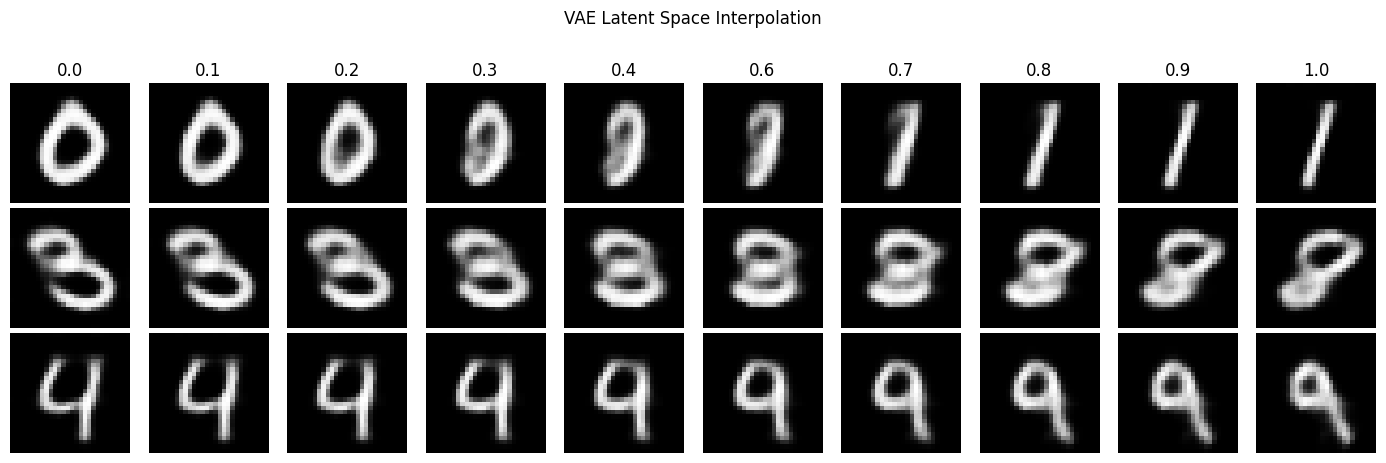

In [10]:
# BEGIN SOLUTION - complete the code in torch.no_grad()
torch.manual_seed(503)
vae.eval()

pairs   = [(0, 1), (3, 8), (4, 9)]   # (source_digit, target_digit)
n_steps = 10
alphas  = torch.linspace(0, 1, n_steps)

# Find one test-set image per digit class
class_to_idx: dict[int, int] = {}
for idx, (_, label) in enumerate(test_dataset):
    if label not in class_to_idx:
        class_to_idx[label] = idx
    if len(class_to_idx) == 10:
        break

fig_interp, axes_interp = plt.subplots(len(pairs), n_steps, figsize=(14, 4.5))

with torch.no_grad():
    for row, (src_digit, tgt_digit) in enumerate(pairs):
        x_src, _ = test_dataset[class_to_idx[src_digit]]
        x_tgt, _ = test_dataset[class_to_idx[tgt_digit]]

        x_src = x_src.unsqueeze(0).to(device)
        x_tgt = x_tgt.unsqueeze(0).to(device)

        mu_src, _ = vae.encoder(x_src)
        mu_tgt, _ = vae.encoder(x_tgt)

        if row == 0:
            for col, alpha in enumerate(alphas):
                axes_interp[row, col].set_title(f"{alpha.item():.1f}")

        for col, alpha in enumerate(alphas):
            z = (1 - alpha) * mu_src + alpha * mu_tgt
            x_dec = vae.decoder(z)

            ax = axes_interp[row, col]
            ax.imshow(x_dec.squeeze().cpu(), cmap="gray")
            ax.axis("off")

        axes_interp[row, 0].set_ylabel(f"{src_digit}→{tgt_digit}", rotation=0, labelpad=28, va="center")

fig_interp.suptitle('VAE Latent Space Interpolation', y=1.02)
plt.tight_layout()
plt.show()
# END SOLUTION

### Exercise 6 (Plot 2): Generating New Digits

Sample from the prior $z \sim N(0, I)$ and decode to generate new images.

**Tasks:**
1. Sample 25 latent vectors of shape `(25, LATENT_DIM)`.
2. Decode with `vae.decoder` to obtain images of shape `(25, 1, 28, 28)`.
3. Display in a **5×5 grid** with `cmap='gray'` and no axes.

**Variables to define:** `fig_gen`, `axes_gen`

**Use `torch.manual_seed(503)` before sampling.**

*This plot is evaluated visually.*

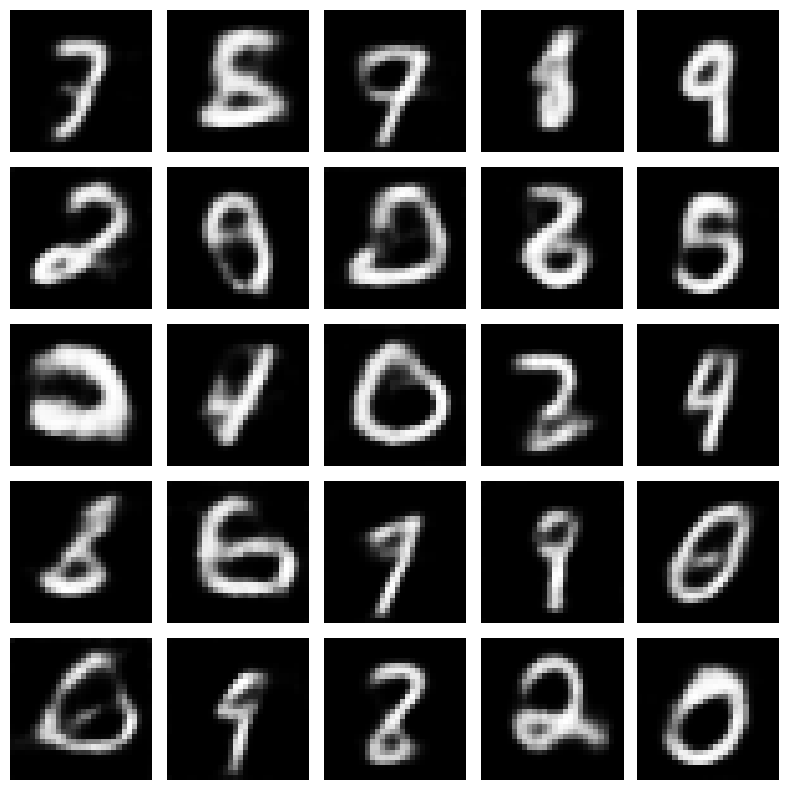

In [11]:
# BEGIN SOLUTION
torch.manual_seed(503)
vae.eval()

with torch.no_grad():
    z = torch.randn(25, LATENT_DIM, device=device)
    imgs = vae.decoder(z).cpu()

    fig_gen, axes_gen = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes_gen.flat):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
# END SOLUTION

---
## Section 2: Denoising Diffusion Probabilistic Models (DDPMs)

### What is a Diffusion Model?

Diffusion models learn to **reverse a gradual noising process**.
A forward process corrupts data over $T$ steps; a neural network learns to undo
it — generating clean images by iteratively denoising pure Gaussian noise.

---

### Forward Process

$$q(x_t \mid x_{t-1}) = N\!\left(\sqrt{1-\beta_t}\,x_{t-1},\;\beta_t I\right)$$

With $\bar{\alpha}_t = \prod_{s=1}^{t}(1-\beta_s)$, we can jump directly to any $x_t$:

$$\boxed{x_t = \sqrt{\bar{\alpha}_t}\;x_0 + \sqrt{1-\bar{\alpha}_t}\;\varepsilon, \qquad \varepsilon \sim N(0,I)}$$

With $T=1000$ and a **cosine variance schedule**, $\bar{\alpha}_T$ decays smoothly to near zero — essentially pure noise.

---

### Training Objective

$$L_{\text{DDPM}} = \mathbb{E}_{t,\,x_0,\,\varepsilon}\!\left[\|\varepsilon - \varepsilon_\theta(x_t,t)\|^2\right]$$

---

### Reverse Process

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\varepsilon_\theta(x_t,t)\right) + \sqrt{\beta_t}\,z, \quad z\sim N(0,I)$$

At $t=0$ omit the noise term. **Images are rescaled to $[-1,1]$ before diffusing.**

### The Denoiser: U-Net

The noise predictor $\varepsilon_\theta(x_t, t)$ is a **U-Net** with:

| Component | Role |
|---|---|
| **Sinusoidal timestep embeddings** | Encode integer $t$ as a fixed-dim vector |
| **Encoder (3 levels)** | Stride-2 convolutions halve spatial resolution |
| **Bottleneck + Self-Attention** | Processing at 7×7 with single-head spatial attention |
| **Decoder (3 levels)** | Transposed convolutions + skip connections back to 28×28 |
| **Time conditioning** | Timestep embedding projected and added to every feature map |

**Self-attention at the bottleneck** (7×7 = 49 tokens) lets every spatial position attend
to every other at the coarsest scale — cheaply capturing global structure that convolutions
miss. This follows the design in Nichol & Dhariwal (2021)
*[Improved Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2102.09672)*.

The U-Net code is provided — **do not modify it**.

In [12]:
# ── Provided: U-Net for DDPM on 28×28 MNIST ─────────────────────────────────

class SinusoidalPositionEmbeddings(nn.Module):
    """Fixed sinusoidal timestep embeddings (Vaswani et al., 2017)."""
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        angles = t[:, None] * freqs[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=-1)


class SelfAttention2d(nn.Module):
    """
    Single-head self-attention over spatial positions.
    Applied at the 7×7 bottleneck (49 tokens) — cheap but globally informative.
    Residual connection preserves local features from the conv branch.
    """
    def __init__(self, ch: int) -> None:
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv  = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h    = self.norm(x)
        q, k, v = self.qkv(h).chunk(3, dim=1)          # each (B, C, H, W)
        scale   = C ** -0.5
        q = q.reshape(B, C, -1).transpose(1, 2)        # (B, HW, C)
        k = k.reshape(B, C, -1)                         # (B, C, HW)
        v = v.reshape(B, C, -1).transpose(1, 2)        # (B, HW, C)
        attn = torch.softmax(q @ k * scale, dim=-1)    # (B, HW, HW)
        out  = (attn @ v).transpose(1, 2).reshape(B, C, H, W)
        return x + self.proj(out)                       # residual


class SimpleUNet(nn.Module):
    """
    3-level U-Net noise predictor for 28×28 MNIST.
    Input : (B, 1, 28, 28) noisy image  +  (B,) integer timestep
    Output: (B, 1, 28, 28) predicted noise
    """
    def __init__(self, in_ch: int = 1, base_dim: int = 64, time_dim: int = 128) -> None:
        super().__init__()
        D = base_dim
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim * 4), nn.GELU(),  # wider MLP
            nn.Linear(time_dim * 4, time_dim),
        )
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, D,   3, padding=1),         nn.GroupNorm(8, D),   nn.GELU())  # 28→28
        self.enc2 = nn.Sequential(nn.Conv2d(D,   D*2, 3, stride=2, padding=1), nn.GroupNorm(8, D*2), nn.GELU())  # 28→14
        self.enc3 = nn.Sequential(nn.Conv2d(D*2, D*4, 3, stride=2, padding=1), nn.GroupNorm(8, D*4), nn.GELU())  # 14→7
        # Time projections (one per level + bottleneck)
        self.t1  = nn.Linear(time_dim, D)
        self.t2  = nn.Linear(time_dim, D*2)
        self.t3  = nn.Linear(time_dim, D*4)
        self.t_m = nn.Linear(time_dim, D*4)
        # Bottleneck + self-attention
        self.mid  = nn.Sequential(nn.Conv2d(D*4, D*4, 3, padding=1), nn.GroupNorm(8, D*4), nn.GELU())
        self.attn = SelfAttention2d(D*4)
        # Decoder (skip connections double input channels)
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(D*8, D*2, 4, stride=2, padding=1), nn.GroupNorm(8, D*2), nn.GELU())  # 7→14
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(D*4, D,   4, stride=2, padding=1), nn.GroupNorm(8, D),   nn.GELU())  # 14→28
        self.out  = nn.Conv2d(D*2, in_ch, 3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        te = self.time_mlp(t)
        h1 = self.enc1(x)  + self.t1(te)[:, :, None, None]
        h2 = self.enc2(h1) + self.t2(te)[:, :, None, None]
        h3 = self.enc3(h2) + self.t3(te)[:, :, None, None]
        h  = self.mid(h3)  + self.t_m(te)[:, :, None, None]   # time into bottleneck
        h  = self.attn(h)                                       # spatial self-attention
        h  = self.dec3(torch.cat([h,  h3], dim=1))
        h  = self.dec2(torch.cat([h,  h2], dim=1))
        return self.out(torch.cat([h,  h1], dim=1))

In [13]:
# ── Tutorial: DDPM noise schedule ────────────────────────────────────────────

def cosine_beta_schedule(T: int, epsilon: float = 0.008) -> torch.Tensor:
    """
    Cosine variance schedule from Nichol & Dhariwal (2021).

    ᾱ_t = cos²(((t/T + ε) / (1+ε)) · π/2)

    Compared to the original linear schedule (Ho et al., 2020), ᾱ_t decays
    more gently — less noise is added in the early steps, preserving image
    structure longer and producing sharper samples.
    Reference: https://arxiv.org/abs/2102.09672
    """
    steps = torch.linspace(0, T, T + 1)
    f_t   = torch.cos(((steps / T + epsilon) / (1 + epsilon)) * math.pi / 2) ** 2
    betas = torch.clip(1 - f_t[1:] / f_t[:T], 0.0, 0.999)
    return betas

T          = 1000
betas      = cosine_beta_schedule(T).to(device)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

print(f"T={T},  β ∈ [{betas[0]:.6f}, {betas[-1]:.4f}]")
print(f"ᾱ_0   = {alpha_bars[0]:.6f}  (almost no noise)")
print(f"ᾱ_999 = {alpha_bars[-1]:.2e}  (essentially pure noise)")


def q_sample(
    x_0:        torch.Tensor,
    t:          torch.Tensor,
    alpha_bars: torch.Tensor,
    noise:      torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Closed-form forward sample: x_t ~ q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x_0)
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    return ab.sqrt() * x_0 + (1 - ab).sqrt() * noise, noise


# Sanity-check
torch.manual_seed(503)
unet = SimpleUNet().to(device)
_xr  = torch.randn(2, 1, 28, 28).to(device)
_tr  = torch.randint(0, T, (2,)).to(device)
print(f"\nU-Net output : {unet(_xr, _tr).shape}  (expected (2, 1, 28, 28))")
print(f"U-Net params : {sum(p.numel() for p in unet.parameters()):,}")

T=1000,  β ∈ [0.000041, 0.9990]
ᾱ_0   = 0.999959  (almost no noise)
ᾱ_999 = 2.43e-09  (essentially pure noise)

U-Net output : torch.Size([2, 1, 28, 28])  (expected (2, 1, 28, 28))
U-Net params : 2,759,809


### DDPM Training Loop (Provided)

Trains the U-Net to predict $\varepsilon$ over 25 epochs.
Images are rescaled to $[-1,1]$ before diffusing.

Three training improvements are used here:

| Technique | What it does | Reference |
|---|---|---|
| **AdamW** | Adam with *decoupled* weight decay — regularises weights without distorting adaptive gradient scaling | [Loshchilov & Hutter, 2019](https://arxiv.org/abs/1711.05101) |
| **OneCycleLR** | Linear warmup (10 % of steps) then cosine anneal — reaches a high LR quickly, avoids oscillating at the end | [Smith & Topin, 2019](https://arxiv.org/abs/1708.07120); [PyTorch docs](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.OneCycleLR.html) |
| **Gradient clipping** | `clip_grad_norm_(params, 1.0)` — caps the global gradient norm, preventing large updates from destabilising training | Standard practice in diffusion / transformer work |

*Expected training time: ~8–10 minutes on a T4 GPU.*

In [14]:
# ── Tutorial: DDPM training (run as-is) ──────────────────────────────────────
torch.manual_seed(503)

DDPM_EPOCHS   = 25
total_steps   = DDPM_EPOCHS * len(train_loader)

ddpm_optimizer = torch.optim.AdamW(unet.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler      = torch.optim.lr_scheduler.OneCycleLR(
    ddpm_optimizer, max_lr=2e-4,
    total_steps=total_steps, pct_start=0.1, anneal_strategy='cos',
)
ddpm_losses: list[float] = []

for epoch in range(1, DDPM_EPOCHS + 1):
    unet.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_0        = (x_batch * 2 - 1).to(device)           # [0,1] → [-1,1]
        t_idx      = torch.randint(0, T, (x_0.shape[0],), device=device)
        x_t, noise = q_sample(x_0, t_idx, alpha_bars)
        pred       = unet(x_t, t_idx)
        loss       = F.mse_loss(pred, noise)
        ddpm_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        ddpm_optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    ddpm_losses.append(epoch_loss)
    print(f"Epoch {epoch:02d}/{DDPM_EPOCHS} | loss: {epoch_loss:.6f}"
          f" | lr: {scheduler.get_last_lr()[0]:.2e}")

unet.eval()
print("\nDDPM training complete.")

Epoch 01/25 | loss: 0.340509 | lr: 7.44e-05
Epoch 02/25 | loss: 0.081402 | lr: 1.82e-04
Epoch 03/25 | loss: 0.066380 | lr: 2.00e-04
Epoch 04/25 | loss: 0.058958 | lr: 1.98e-04
Epoch 05/25 | loss: 0.054660 | lr: 1.94e-04
Epoch 06/25 | loss: 0.052184 | lr: 1.88e-04
Epoch 07/25 | loss: 0.050326 | lr: 1.81e-04
Epoch 08/25 | loss: 0.048649 | lr: 1.72e-04
Epoch 09/25 | loss: 0.047565 | lr: 1.62e-04
Epoch 10/25 | loss: 0.046961 | lr: 1.50e-04
Epoch 11/25 | loss: 0.045740 | lr: 1.37e-04
Epoch 12/25 | loss: 0.045328 | lr: 1.24e-04
Epoch 13/25 | loss: 0.045089 | lr: 1.10e-04
Epoch 14/25 | loss: 0.044210 | lr: 9.65e-05
Epoch 15/25 | loss: 0.044132 | lr: 8.26e-05
Epoch 16/25 | loss: 0.043539 | lr: 6.91e-05
Epoch 17/25 | loss: 0.043290 | lr: 5.61e-05
Epoch 18/25 | loss: 0.042780 | lr: 4.41e-05
Epoch 19/25 | loss: 0.042738 | lr: 3.31e-05
Epoch 20/25 | loss: 0.042748 | lr: 2.34e-05
Epoch 21/25 | loss: 0.042269 | lr: 1.52e-05
Epoch 22/25 | loss: 0.042295 | lr: 8.63e-06
Epoch 23/25 | loss: 0.042081 | l

In [15]:
# ── Provided: clipped reverse diffusion + sampling wrapper ───────────────────

@torch.no_grad()
def p_sample_clipped(
    model:      nn.Module,
    x_t:        torch.Tensor,
    t_idx:      int,
    betas:      torch.Tensor,
    alphas:     torch.Tensor,
    alpha_bars: torch.Tensor,
) -> torch.Tensor:
    """
    One reverse step using the x̂₀-prediction + clip trick (Nichol & Dhariwal, 2021).

    Instead of stepping directly with the predicted noise (numerically fragile at
    small ᾱ_t), we:
      1. Predict ε, then recover  x̂₀ = (x_t − √(1−ᾱ_t)·ε) / √ᾱ_t
      2. Clip x̂₀ to [−1, 1]  ← key stabiliser
      3. Compute the true posterior mean q(x_{t−1} | x̂₀, x_t)
    """
    B      = x_t.shape[0]
    t_full = torch.full((B,), t_idx, device=x_t.device, dtype=torch.long)
    ab_t   = alpha_bars[t_idx]
    a_t    = alphas[t_idx]
    b_t    = betas[t_idx]

    pred_noise = model(x_t, t_full)

    # recover and clip x̂₀
    x0_pred = (x_t - (1 - ab_t).sqrt() * pred_noise) / ab_t.sqrt()
    x0_pred = x0_pred.clamp(-1.0, 1.0)

    # posterior mean
    if t_idx > 0:
        ab_prev = alpha_bars[t_idx - 1]
        mean = (
            (b_t * ab_prev.sqrt() / (1 - ab_t)) * x0_pred
          + ((1 - ab_prev) * a_t.sqrt() / (1 - ab_t)) * x_t
        )
        std = (b_t * (1 - ab_prev) / (1 - ab_t)).sqrt()
        return mean + std * torch.randn_like(x_t)
    else:
        return (b_t / (1 - ab_t)) * x0_pred   # no noise at t = 0


@torch.no_grad()
def sample_images(
    model:      nn.Module,
    n:          int,
    T:          int,
    betas:      torch.Tensor,
    alphas:     torch.Tensor,
    alpha_bars: torch.Tensor,
) -> torch.Tensor:
    """Full reverse loop: x_T ~ N(0,I) → x_0, returned in [0, 1]."""
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    for t in reversed(range(T)):
        x = p_sample_clipped(model, x, t, betas, alphas, alpha_bars)
    return ((x.clamp(-1, 1) + 1) / 2)   # [-1,1] → [0,1]

### Exercise 7 (Plot 3): Visualizing the Forward Diffusion Process

Watch a clean MNIST digit progressively corrupted into noise.

**Tasks:**
1. Retrieve one image from `test_dataset` (index 0). Rescale to $[-1,1]$: `x_0 = x * 2 - 1`.
2. Apply `q_sample` at $t \in \{0, 200, 400, 600, 800, 999\}$.
3. Display the 6 images side-by-side; title each with its timestep.
   Map back to $[0,1]$ for display: `(img + 1) / 2`. Use `cmap='gray'` and `.squeeze()`.

**Variables to define:** `fig_noise`, `axes_noise`

**Use `torch.manual_seed(503)` before the first `q_sample` call.**

*This plot is evaluated visually — the digit should progress from sharp to pure noise.*

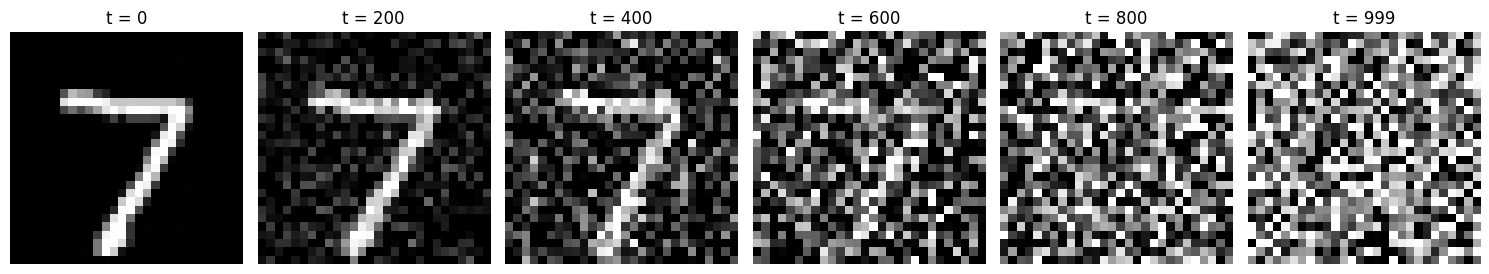

In [16]:
# BEGIN SOLUTION
torch.manual_seed(503)

x_0, _ = test_dataset[0]
x_0 = (x_0 * 2 - 1).unsqueeze(0).to(device)

timesteps = [0, 200, 400, 600, 800, 999]

fig_noise, axes_noise = plt.subplots(1, len(timesteps), figsize=(15, 3))

with torch.no_grad():
    for ax, t in zip(axes_noise, timesteps):
        t_tensor = torch.tensor([t], device=device)
        x_t, _ = q_sample(x_0, t_tensor, alpha_bars)
        img = ((x_t.squeeze() + 1) / 2).clamp(0, 1).cpu()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"t = {t}")
        ax.axis('off')

plt.tight_layout()
plt.show()
# END SOLUTION

### Exercise 8 (Plot 4): Generating Digits with DDPM

Use the provided `sample_images` function to run the full reverse diffusion process
and display the generated digits.

**Tasks:**
1. Call `sample_images(unet, n=25, T=T, betas=betas, alphas=alphas, alpha_bars=alpha_bars)`.
   The function starts from $x_T \sim N(0,I)$ and iterates the clipped reverse
   step 1 000 times, returning images already in $[0, 1]$.
2. Display the 25 generated images in a **5×5 grid** with `cmap='gray'` and no axes.

**Variables to define:** `fig_ddpm`, `axes_ddpm`

**Use `torch.manual_seed(123)` before calling `sample_images`.**

*This plot is evaluated visually.*

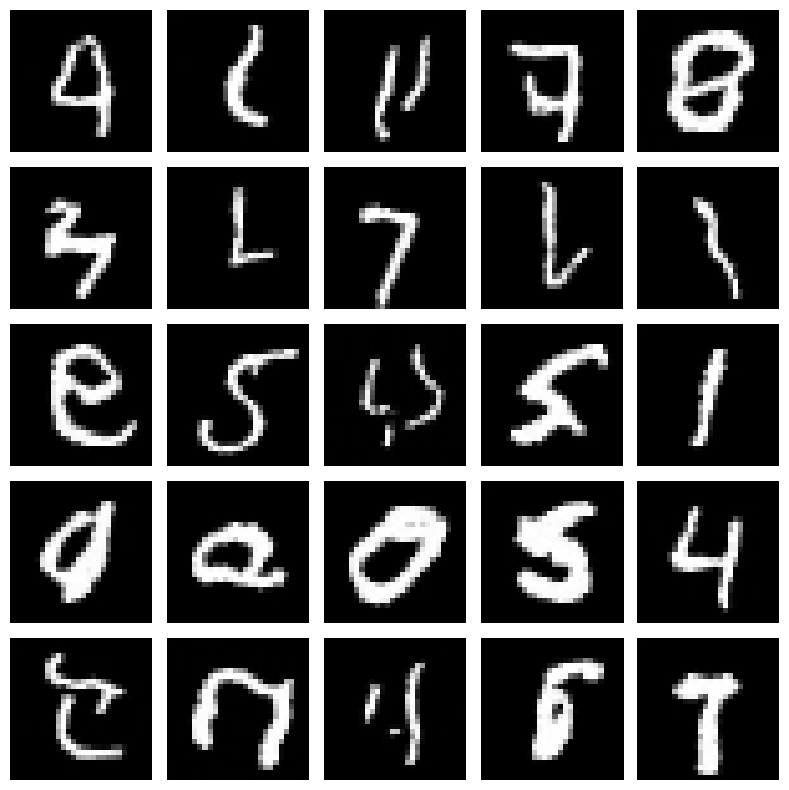

In [17]:
# BEGIN SOLUTION
torch.manual_seed(123)

with torch.no_grad():
    imgs_ddpm = sample_images(unet, n=25, T=T, betas=betas, alphas=alphas, alpha_bars=alpha_bars).cpu()

    fig_ddpm, axes_ddpm = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes_ddpm.flat):
        ax.imshow(imgs_ddpm[i].squeeze(), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
# END SOLUTION